In [1]:
import numpy as np
import nibabel as nib
import itertools
from pathlib import Path
import matplotlib.pyplot as plt

# 1. 設定基礎路徑 (請確認替換為你的實際路徑)
base_dir = Path(r"D:\NTU_PSY\Documents\Patric_Asen_BrainHackProject")

# 2. 設定受試者與概念清單
subjects = ["sub-01", "sub-02", "sub-03"]

# 填入挑選的 35 個concepts
folder = Path(base_dir / "affordance candidate")

affordance_candidates = [
    p.stem for p in folder.iterdir()
    if p.suffix.lower() in [".jpg", ".png", ".jpeg"]
]

print(affordance_candidates)

affordance_candidates_list = affordance_candidates 

# 3. 設定各個 ROI 在 Atlas 中的 ID
VVC_ids = [163, 1163] 
AIP_ids = [117, 1117]  
IPL_ids = [105, 116, 147, 148, 149] 
vPM_ids = [56, 1056] 
roi_names = ["VVC", "AIP", "IPL", "vPM"]

# 4. 讀取已經對齊好的 Atlas 影像
# 確保這個 Atlas 的維度與 fMRI Beta 影像 (72, 91, 75) 是一致的
atlas_path = base_dir / "HCP_atlas\MNI_Glasser_HCP_v1.0.nii.gz" 
atlas_img = nib.load(atlas_path)
atlas_resampled_data = atlas_img.get_fdata()

print("✅ [Cell 1 執行完畢] 前置工作完成：模組載入、路徑設定、Atlas 讀取完畢！")

['broom', 'brush', 'calculator', 'comb', 'corkscrew', 'crowbar', 'crutch', 'dustpan', 'flyswatter', 'gearshift', 'glass', 'grenade', 'hairbrush', 'hammer', 'jar', 'joystick', 'knife', 'magnifying_glass', 'match', 'needle', 'pencil', 'phone', 'ruler', 'scissors', 'screwdriver', 'shovel', 'silverware', 'spatula', 'spoon', 'squeegee', 'sword', 'tongs', 'trowel', 'tweezers', 'typewriter']
✅ [Cell 1 執行完畢] 前置工作完成：模組載入、路徑設定、Atlas 讀取完畢！


⏳ 開始載入所有受試者的fMRI Volume 資料...
-> 正在處理 sub-01 ...
   [資訊] 偵測到 Shape 差異 ((72, 91, 75) vs (256, 256, 256))，進行 Atlas 線性重採樣...
-> 正在處理 sub-02 ...
   [資訊] 偵測到 Shape 差異 ((72, 94, 75) vs (256, 256, 256))，進行 Atlas 線性重採樣...
-> 正在處理 sub-03 ...
   [資訊] 偵測到 Shape 差異 ((71, 83, 73) vs (256, 256, 256))，進行 Atlas 線性重採樣...
✅ 所有受試者之 fMRI ROI 資料載入完畢！
✅ 所有 ROI 的 RDM 計算與平均儲存完成！


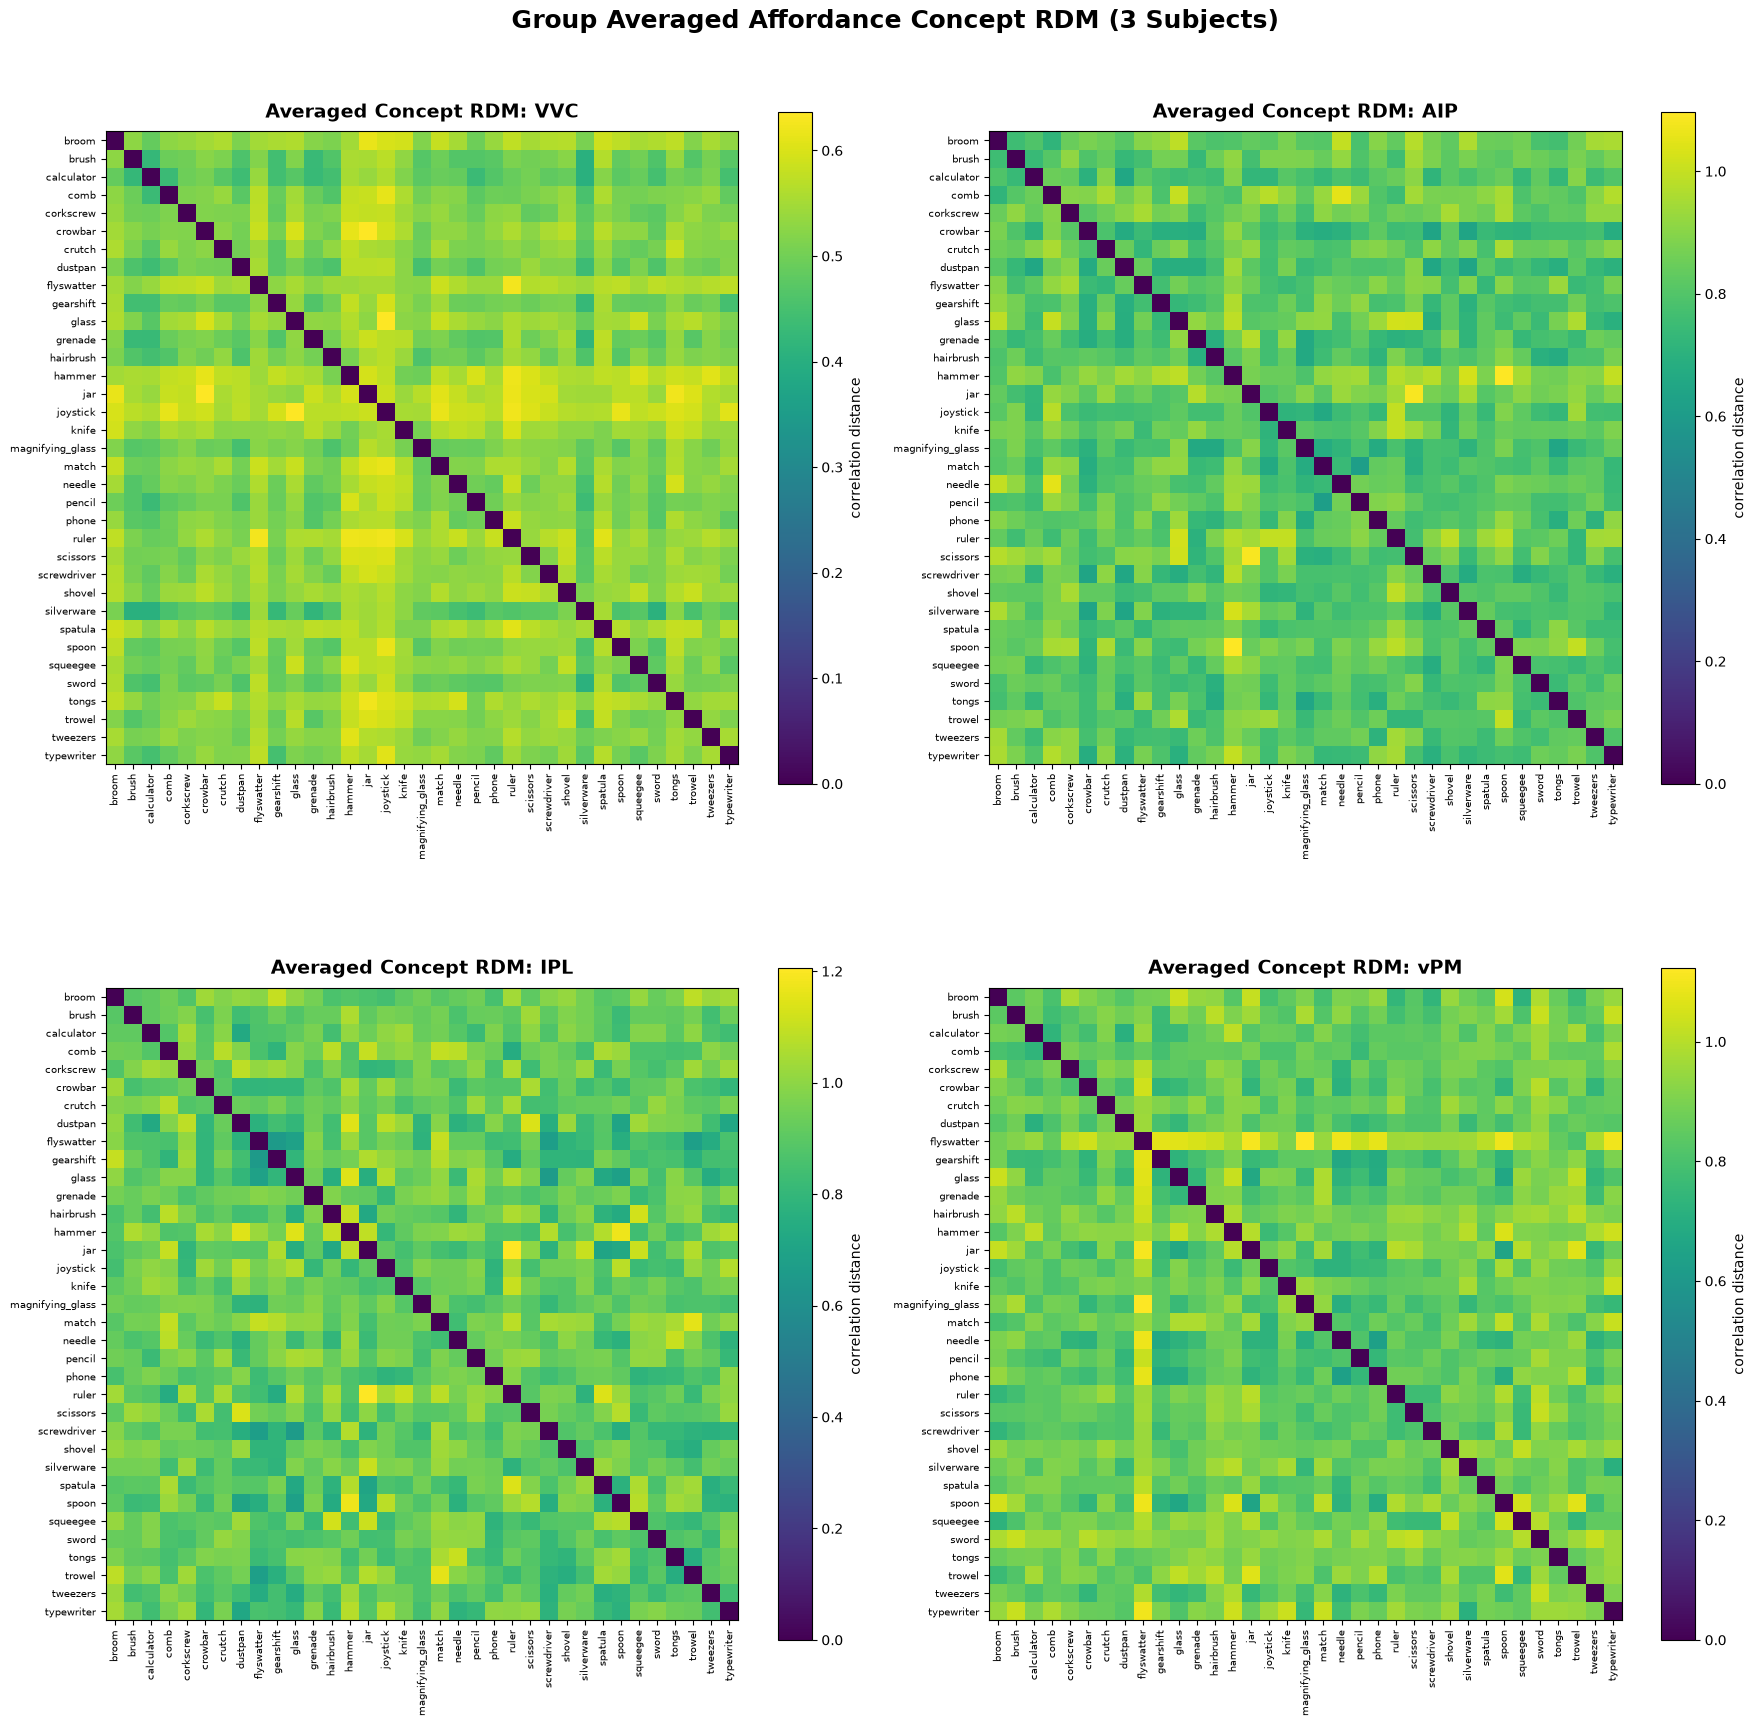

In [2]:
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from nilearn.image import resample_to_img

# 1. 定義輔助函式：載入與篩選特定受試者的條件表 (sub-01, sub-02, sub-03 各自的 CSV)
def load_and_filter_conditions(base_dir, sub_id, targets, verbose=True):
    # 動態讀取對應受試者的 CSV 檔案，例如 sub-02_condition_with_ratings.csv
    path = base_dir / "subject_fMRI_nii" / f"{sub_id}_condition_with_ratings.csv"
    df = pd.read_csv(path)
    df_selected = df[df["concept"].isin(targets)].copy()
    df_selected["concept"] = pd.Categorical(df_selected["concept"], categories=targets, ordered=True)
    df_selected = df_selected.sort_values(by=["concept"]).reset_index(drop=True)
    return df_selected

# 2. 定義輔助函式：讀取指定受試者的 fMRI Volume (自 subject_fMRI_nii 下的各別子資料夾提取)
def extract_fmri_volumes_rowwise(df_sorted, base_dir, sub_id):
    grouped = df_sorted.groupby(["session", "run"])
    
    # 預先取得該受試者第一個 volume 的 shape
    first_row = df_sorted.iloc[0]
    first_path = (
        base_dir / 
        "subject_fMRI_nii" / 
        sub_id / 
        first_row.session / 
        f"{sub_id}_{first_row.session}_run-{first_row.run:02d}_betas.nii"
    )
    first_img = nib.load(first_path)
    vol_shape = first_img.shape[:3]
    
    n_trials = len(df_sorted)
    volumes = np.zeros(vol_shape + (n_trials,), dtype=np.float32)
    concept_labels = [None] * n_trials
    
    for (session, run), group in grouped:
        # 從各受試者專屬的子資料夾 (如 subject_fMRI_nii/sub-02/) 讀取對應 betas.nii 檔案
        img_path = (
            base_dir / 
            "subject_fMRI_nii" / 
            sub_id / 
            session / 
            f"{sub_id}_{session}_run-{run:02d}_betas.nii"
        )
        img = nib.load(img_path)
        data = img.get_fdata(dtype=np.float32)
        
        for row in group.itertuples():
            t = int(row.trial_idx)
            volumes[..., row.Index] = data[..., t]
            concept_labels[row.Index] = row.concept
            
    return volumes, np.array(concept_labels)

# 3. 逐一讀取 3 位受試者的 fMRI 資料，並針對各個 ROI 進行遮罩與特徵提取
subject_roi_data = {roi: {} for roi in roi_names}
roi_dict = {
    "VVC": VVC_ids,
    "AIP": AIP_ids,
    "IPL": IPL_ids,
    "vPM": vPM_ids
}
unique_concepts = affordance_candidates_list

print("⏳ 開始載入所有受試者的fMRI Volume 資料...")

for sub in subjects:
    print(f"-> 正在處理 {sub} ...")
    # 動態傳入受試者代號 (sub-01, sub-02, sub-03)，分別載入其個別的 CSV 與 fMRI Volume 檔案
    df_sub = load_and_filter_conditions(base_dir, sub, affordance_candidates_list)
    selected_volumes, concept_labels = extract_fmri_volumes_rowwise(df_sub, base_dir, sub)
    
    # 動態檢查 Shape 是否與 atlas_resampled_data 吻合，若不吻合則動態對該受試者進行 Resampling
    vol_shape = selected_volumes.shape[:3]
    if vol_shape == atlas_resampled_data.shape:
        subject_atlas = atlas_resampled_data
    else: 
        print(f"   [資訊] 偵測到 Shape 差異 ({vol_shape} vs {atlas_resampled_data.shape})，進行 Atlas 線性重採樣...")
        # 讀取該受試者之 reference img 作為重採樣參考
        first_row = df_sub.iloc[0]
        ref_path = (
            base_dir / 
            "subject_fMRI_nii" / 
            sub / 
            first_row.session / 
            f"{sub}_{first_row.session}_run-{first_row.run:02d}_betas.nii"
        )
        ref_img = nib.load(ref_path)
        atlas_rs = resample_to_img(atlas_img, ref_img, interpolation="nearest")
        subject_atlas = atlas_rs.get_fdata()
        
    for roi_name in roi_names:
        roi_ids = roi_dict[roi_name]
        roi_mask = np.isin(subject_atlas, roi_ids)
        roi_data = selected_volumes[roi_mask]
        
        subject_roi_data[roi_name][sub] = {
            "roi_data": roi_data,
            "concept_labels": concept_labels
        }
        
    # 釋放 selected_volumes 的記憶體以避免 MemoryError
    del selected_volumes

print("✅ 所有受試者之 fMRI ROI 資料載入完畢！")

# 4. 計算 RDM，並進行 3 位受試者的平均
avg_concept_rdms = {}
avg_image_rdms = {}

for roi_name in roi_names:
    concept_rdms = []
    image_rdms = []
    
    for sub in subjects:
        data_dict = subject_roi_data[roi_name][sub]
        roi_data = data_dict["roi_data"]
        labels = data_dict["concept_labels"]
        
        trial_pattern = roi_data.T # (trials, voxels)
        
        # A. 計算 Concept-based RDM (35 x 35)
        concept_patterns = []
        for c in unique_concepts:
            idx = np.where(labels == c)[0]
            concept_patterns.append(trial_pattern[idx].mean(axis=0))
        concept_patterns = np.vstack(concept_patterns)
        
        sub_concept_rdm = squareform(pdist(concept_patterns, metric="correlation"))
        concept_rdms.append(sub_concept_rdm)
        
        # B. 計算 Image-based RDM (420 x 420)
        sub_image_rdm = squareform(pdist(trial_pattern, metric="correlation"))
        image_rdms.append(sub_image_rdm)
        
    # 計算受試者平均 RDM
    avg_concept_rdms[roi_name] = np.mean(concept_rdms, axis=0)
    avg_image_rdms[roi_name] = np.mean(image_rdms, axis=0)
    
    # 儲存平均後的 RDM 至 processed_data
    out_dir = base_dir / "processed_data"
    out_dir.mkdir(exist_ok=True)
    np.save(out_dir / f"avg_concept_rdm_{roi_name}.npy", avg_concept_rdms[roi_name])
    np.save(out_dir / f"avg_image_rdm_{roi_name}.npy", avg_image_rdms[roi_name])

print("✅ 所有 ROI 的 RDM 計算與平均儲存完成！")

# 5. 繪製 2x2 子圖的平均 Concept-based RDM 熱圖
fig, axes = plt.subplots(2, 2, figsize=(18, 18))
axes = axes.flatten()

for i, roi_name in enumerate(roi_names):
    ax = axes[i]
    rdm = avg_concept_rdms[roi_name]
    
    im = ax.imshow(rdm, cmap="viridis", interpolation="none")
    ax.set_title(f"Averaged Concept RDM: {roi_name}", fontsize=14, fontweight="bold", pad=10)
    
    ax.set_xticks(np.arange(len(unique_concepts)))
    ax.set_yticks(np.arange(len(unique_concepts)))
    ax.set_xticklabels(unique_concepts, rotation=90, fontsize=7)
    ax.set_yticklabels(unique_concepts, fontsize=7)
    
    plt.colorbar(im, ax=ax, shrink=0.8, label="correlation distance")

plt.suptitle("Group Averaged Affordance Concept RDM (3 Subjects)", fontsize=18, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()


In [8]:
from scipy.stats import spearmanr

# 1. 定義欲進行 RSA 分析的 ROI 組別對
rsa_pairs = [
    ("VVC", "AIP"),
    ("VVC", "IPL"),
    ("VVC", "vPM"),
    ("AIP", "IPL"),
    ("AIP", "vPM"),
    ("IPL", "vPM")
]

results = []
n_concepts = avg_concept_rdms[roi_names[0]].shape[0] 

# 提取對稱矩陣的上三角索引 (不包含對角線本身，k=1)
iu = np.triu_indices(n_concepts, k=1)

print("⏳ 開始進行 ROI 對之間的 RSA 分析 (Spearman correlation distance)...\n")

# 2. 計算各組別 ROI RDM 上三角向量的 Spearman 相關係數及 p-value
for roi_a, roi_b in rsa_pairs:
    vec_a = avg_concept_rdms[roi_a][iu]
    vec_b = avg_concept_rdms[roi_b][iu]
    
    rho, p_val = spearmanr(vec_a, vec_b)
    results.append({
        "ROI A": roi_a,
        "ROI B": roi_b,
        "Spearman rho": rho,
        "p-value": p_val
    })

# 轉換為 DataFrame 美化輸出
df_results = pd.DataFrame(results)
print("=== ROI-to-ROI RSA Pairwise Correlation Results ===")
print(df_results.to_string(index=False))
print("\n===================================================")

""" # 3. 建構對稱的 4x4 ROI-to-ROI 相似度矩陣
rsa_matrix = np.eye(len(roi_names))  # 對角線設為 1.0
for r in results:
    idx_a = roi_names.index(r["ROI A"])
    idx_b = roi_names.index(r["ROI B"])
    
    rsa_matrix[idx_a, idx_b] = r["Spearman rho"]
    rsa_matrix[idx_b, idx_a] = r["Spearman rho"]  # 對稱填充

# 4. 繪製並儲存 ROI-to-ROI RSA 相似度矩陣熱圖
fig, ax = plt.subplots(figsize=(8, 7))
# 使用偏紅藍色調 (RdBu_r) 呈現，範圍設為 -1.0 到 1.0 以正確呈現相關強度
im = ax.imshow(rsa_matrix, cmap="RdBu_r", vmin=-1.0, vmax=1.0, interpolation="none")
ax.set_title("ROI-to-ROI RSA Similarity Matrix (Spearman rho)", fontsize=14, fontweight="bold", pad=15)

ax.set_xticks(np.arange(len(roi_names)))
ax.set_yticks(np.arange(len(roi_names)))
ax.set_xticklabels(roi_names, fontsize=10)
ax.set_yticklabels(roi_names, fontsize=10)

# 在熱圖上方數值標記 (Annotate)
for i in range(len(roi_names)):
    for j in range(len(roi_names)):
        text = ax.text(j, i, f"{rsa_matrix[i, j]:.3f}",
                       ha="center", va="center", 
                       color="black" if abs(rsa_matrix[i, j]) < 0.6 else "white",
                       fontsize=10, fontweight="bold")

plt.colorbar(im, ax=ax, label="Spearman correlation (rho)")
plt.tight_layout()
plt.savefig(base_dir / "processed_data" / "roi_to_roi_rsa_matrix.png", dpi=300)
plt.show()
print("\n✅ ROI-to-ROI RSA 分析繪圖完成，熱圖已儲存至 processed_data/roi_to_roi_rsa_matrix.png 。") """


⏳ 開始進行 ROI 對之間的 RSA 分析 (Spearman correlation distance)...

=== ROI-to-ROI RSA Pairwise Correlation Results ===
ROI A ROI B  Spearman rho      p-value
  VVC   AIP      0.273566 1.130013e-11
  VVC   IPL      0.092703 2.373477e-02
  VVC   vPM      0.137473 7.731217e-04
  AIP   IPL      0.356223 3.054269e-19
  AIP   vPM      0.208869 2.733434e-07
  IPL   vPM      0.157569 1.135883e-04



' # 3. 建構對稱的 4x4 ROI-to-ROI 相似度矩陣\nrsa_matrix = np.eye(len(roi_names))  # 對角線設為 1.0\nfor r in results:\n    idx_a = roi_names.index(r["ROI A"])\n    idx_b = roi_names.index(r["ROI B"])\n\n    rsa_matrix[idx_a, idx_b] = r["Spearman rho"]\n    rsa_matrix[idx_b, idx_a] = r["Spearman rho"]  # 對稱填充\n\n# 4. 繪製並儲存 ROI-to-ROI RSA 相似度矩陣熱圖\nfig, ax = plt.subplots(figsize=(8, 7))\n# 使用偏紅藍色調 (RdBu_r) 呈現，範圍設為 -1.0 到 1.0 以正確呈現相關強度\nim = ax.imshow(rsa_matrix, cmap="RdBu_r", vmin=-1.0, vmax=1.0, interpolation="none")\nax.set_title("ROI-to-ROI RSA Similarity Matrix (Spearman rho)", fontsize=14, fontweight="bold", pad=15)\n\nax.set_xticks(np.arange(len(roi_names)))\nax.set_yticks(np.arange(len(roi_names)))\nax.set_xticklabels(roi_names, fontsize=10)\nax.set_yticklabels(roi_names, fontsize=10)\n\n# 在熱圖上方數值標記 (Annotate)\nfor i in range(len(roi_names)):\n    for j in range(len(roi_names)):\n        text = ax.text(j, i, f"{rsa_matrix[i, j]:.3f}",\n                       ha="center", va="center", \n         

In [10]:
import numpy as np
import nibabel as nib
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from scipy.stats import ttest_1samp

# ====================================================
# 【步驟 1】定義跨類別解碼的分類標籤 (Affordance Labels)
# ====================================================
train_class_0 = "tweezers"  
train_class_1 = "hammer"    
test_class_0 = "tongs"      
test_class_1 = "crowbar"    

roi_ids = AIP_ids
roi_name = "AIP"
subject_accuracies = []

# ====================================================
# 【步驟 2】開始迴圈，針對每位受試者進行機器學習
# ====================================================
print(f"================= 開始執行 {roi_name} 的 SVM 跨類別解碼 =================")

# 準備 ROI Mask -- 移至受試者迴圈中動態處理

for sub in subjects:
    print(f"\n正在訓練與測試受試者: {sub} ...")
    
    # 1. 讀取該受試者的 CSV 條件表
    df_sub = load_and_filter_conditions(
        base_dir=base_dir,
        sub_id=sub,
        targets=[train_class_0, train_class_1, test_class_0, test_class_1],
        verbose=False
    )
    
    # 2. 動態檢查受試者影像的 Shape，並進行 Atlas 線性重採樣以匹配腦區
    first_row = df_sub.iloc[0]
    first_ses_str = first_row['session']
    first_run_str = f"run-{int(first_row['run']):02d}"
    ref_path = base_dir / f"subject_fMRI_nii/{sub}/{first_ses_str}/{sub}_{first_ses_str}_{first_run_str}_betas.nii"
    ref_img = nib.load(ref_path)
    
    if ref_img.shape[:3] == atlas_resampled_data.shape:
        subject_atlas = atlas_resampled_data
    else:
        from nilearn.image import resample_to_img
        atlas_rs = resample_to_img(atlas_img, ref_img, interpolation="nearest")
        subject_atlas = atlas_rs.get_fdata()
        
    roi_mask = np.isin(subject_atlas, roi_ids)
    
    X_train, y_train = [], []
    X_test, y_test = [], []
    
    # 2. 核心修改：依照 session 和 run 進行分組，一批一批讀取 NIfTI 檔案
    for (ses, run), group_df in df_sub.groupby(['session', 'run']):
        
        # 格式化數字為兩位數，例如 1 變成 '01'
        ses_str = ses
        run_str = f"run-{int(run):02d}"
        
        # 組合出正確的巢狀路徑
        # 例: subject_fMRI_nii/sub-01/ses-things01/sub-01_ses-things01_run-01_betas.nii
        nii_path = base_dir / f"subject_fMRI_nii/{sub}/{ses_str}/{sub}_{ses_str}_{run_str}_betas.nii"
        
        if not nii_path.exists():
            print(f"⚠️ 找不到檔案，略過: {nii_path}")
            continue
            
        # 載入該 run 的 fMRI 影像 (通常是 4D: 72 x 91 x 75 x n_trials)
        beta_img = nib.load(nii_path)
        beta_data = beta_img.get_fdata()
        
        # 針對這個 run 裡面「符合我們目標」的幾個 trial 進行特徵提取
        for _, row in group_df.iterrows():
            concept = row['concept']
            
            # ⚠️ 關鍵：找出這個 trial 在該 run (4D影像) 裡是第幾個 Volume
            vol_idx = int(row['trial_idx']) 
            
            # 提取該 Volume 在 AIP 腦區的活化值，壓扁成 1D 向量 (SVM 的 Features)
            voxel_features = beta_data[:, :, :, vol_idx][roi_mask]
            
            # 依據概念分發到 Train 還是 Test，以及給予 y 標籤
            if concept == train_class_0:
                X_train.append(voxel_features)
                y_train.append(0)
            elif concept == train_class_1:
                X_train.append(voxel_features)
                y_train.append(1)
            elif concept == test_class_0:
                X_test.append(voxel_features)
                y_test.append(0)
            elif concept == test_class_1:
                X_test.append(voxel_features)
                y_test.append(1)
                
    # 將 List 轉換為 NumPy Array
    X_train, y_train = np.array(X_train), np.array(y_train)
    X_test, y_test = np.array(X_test), np.array(y_test)
    
    # 檢查是否成功抽取到資料
    if len(X_train) == 0 or len(X_test) == 0:
        print(f"❌ {sub} 沒有足夠的特徵可供訓練，請檢查 CSV 欄位名稱或資料！")
        continue

    # ====================================================
    # 【步驟 3】標準化與 SVM 模型訓練
    # ====================================================
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    svm = SVC(kernel='linear', C=1.0)
    svm.fit(X_train_scaled, y_train)
    
    accuracy = svm.score(X_test_scaled, y_test)
    subject_accuracies.append(accuracy)
    
    print(f"  -> {sub} 提取了 {len(X_train)} 筆訓練 / {len(X_test)} 筆測試資料。解碼準確率: {accuracy*100:.2f}%")

# ====================================================
# 【步驟 4】群體統計檢定
# ====================================================
if len(subject_accuracies) > 0:
    print("\n================= 群體統計結果 =================")
    mean_acc = np.mean(subject_accuracies)
    print(f"{roi_name} 群體平均準確率: {mean_acc*100:.2f}% (隨機水準為 50.00%)")

    t_stat, p_val = ttest_1samp(subject_accuracies, popmean=0.5, alternative='greater')
    print(f"單一樣本 t 檢定: t-value = {t_stat:.4f}, p-value = {p_val:.4f}")

    if p_val < 0.05:
        print(f"🎉 恭喜！{roi_name} 腦區的解碼準確率顯著高於 50%！")
    else:
        print(f"⚠️ {roi_name} 腦區的解碼未達統計顯著。")

================= 開始執行 AIP 的 SVM 跨類別解碼 =================

正在訓練與測試受試者: sub-01 ...
  -> sub-01 提取了 24 筆訓練 / 24 筆測試資料。解碼準確率: 45.83%

正在訓練與測試受試者: sub-02 ...
  -> sub-02 提取了 24 筆訓練 / 24 筆測試資料。解碼準確率: 50.00%

正在訓練與測試受試者: sub-03 ...
  -> sub-03 提取了 24 筆訓練 / 24 筆測試資料。解碼準確率: 33.33%

================= 群體統計結果 =================
AIP 群體平均準確率: 43.06% (隨機水準為 50.00%)
單一樣本 t 檢定: t-value = -1.3868, p-value = 0.8501
⚠️ AIP 腦區的解碼未達統計顯著。


In [ ]:
import numpy as np
import nibabel as nib
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from scipy.stats import ttest_1samp

# ====================================================
# 【步驟 1】定義跨類別解碼的分類標籤 (Affordance Labels)
# ====================================================
train_class_0 = "tweezers"  
train_class_1 = "hammer"    
test_class_0 = "tongs"      
test_class_1 = "crowbar"    

roi_ids = IPL_ids
roi_name = "IPL"
subject_accuracies = []

# ====================================================
# 【步驟 2】開始迴圈，針對每位受試者進行機器學習
# ====================================================
print(f"================= 開始執行 {roi_name} 的 SVM 跨類別解碼 =================")

# 準備 ROI Mask -- 移至受試者迴圈中動態處理

for sub in subjects:
    print(f"\n正在訓練與測試受試者: {sub} ...")
    
    # 1. 讀取該受試者的 CSV 條件表
    df_sub = load_and_filter_conditions(
        base_dir=base_dir,
        sub_id=sub,
        targets=[train_class_0, train_class_1, test_class_0, test_class_1],
        verbose=False
    )
    
    # 2. 動態檢查受試者影像的 Shape，並進行 Atlas 線性重採樣以匹配腦區
    first_row = df_sub.iloc[0]
    first_ses_str = first_row['session']
    first_run_str = f"run-{int(first_row['run']):02d}"
    ref_path = base_dir / f"subject_fMRI_nii/{sub}/{first_ses_str}/{sub}_{first_ses_str}_{first_run_str}_betas.nii"
    ref_img = nib.load(ref_path)
    
    if ref_img.shape[:3] == atlas_resampled_data.shape:
        subject_atlas = atlas_resampled_data
    else:
        from nilearn.image import resample_to_img
        atlas_rs = resample_to_img(atlas_img, ref_img, interpolation="nearest")
        subject_atlas = atlas_rs.get_fdata()
        
    roi_mask = np.isin(subject_atlas, roi_ids)
    
    X_train, y_train = [], []
    X_test, y_test = [], []
    
    # 2. 核心修改：依照 session 和 run 進行分組，一批一批讀取 NIfTI 檔案
    for (ses, run), group_df in df_sub.groupby(['session', 'run']):
        
        # 格式化數字為兩位數，例如 1 變成 '01'
        ses_str = ses
        run_str = f"run-{int(run):02d}"
        
        # 組合出正確的巢狀路徑
        # 例: subject_fMRI_nii/sub-01/ses-things01/sub-01_ses-things01_run-01_betas.nii
        nii_path = base_dir / f"subject_fMRI_nii/{sub}/{ses_str}/{sub}_{ses_str}_{run_str}_betas.nii"
        
        if not nii_path.exists():
            print(f"⚠️ 找不到檔案，略過: {nii_path}")
            continue
            
        # 載入該 run 的 fMRI 影像 (通常是 4D: 72 x 91 x 75 x n_trials)
        beta_img = nib.load(nii_path)
        beta_data = beta_img.get_fdata()
        
        # 針對這個 run 裡面「符合我們目標」的幾個 trial 進行特徵提取
        for _, row in group_df.iterrows():
            concept = row['concept']
            
            # ⚠️ 關鍵：找出這個 trial 在該 run (4D影像) 裡是第幾個 Volume    
            vol_idx = int(row['trial_idx']) 
            
            # 提取該 Volume 在 IPL 腦區的活化值，壓扁成 1D 向量 (SVM 的 Features)
            voxel_features = beta_data[:, :, :, vol_idx][roi_mask]
            
            # 依據概念分發到 Train 還是 Test，以及給予 y 標籤
            if concept == train_class_0:
                X_train.append(voxel_features)
                y_train.append(0)
            elif concept == train_class_1:
                X_train.append(voxel_features)
                y_train.append(1)
            elif concept == test_class_0:
                X_test.append(voxel_features)
                y_test.append(0)
            elif concept == test_class_1:
                X_test.append(voxel_features)
                y_test.append(1)
                
    # 將 List 轉換為 NumPy Array
    X_train, y_train = np.array(X_train), np.array(y_train)
    X_test, y_test = np.array(X_test), np.array(y_test)
    
    # 檢查是否成功抽取到資料
    if len(X_train) == 0 or len(X_test) == 0:
        print(f"❌ {sub} 沒有足夠的特徵可供訓練，請檢查 CSV 欄位名稱或資料！")
        continue

    # ====================================================
    # 【步驟 3】標準化與 SVM 模型訓練
    # ====================================================
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    svm = SVC(kernel='linear', C=1.0)
    svm.fit(X_train_scaled, y_train)
    
    accuracy = svm.score(X_test_scaled, y_test)
    subject_accuracies.append(accuracy)
    
    print(f"  -> {sub} 提取了 {len(X_train)} 筆訓練 / {len(X_test)} 筆測試資料。解碼準確率: {accuracy*100:.2f}%")

# ====================================================
# 【步驟 4】群體統計檢定
# ====================================================
if len(subject_accuracies) > 0:
    print("\n================= 群體統計結果 =================")
    mean_acc = np.mean(subject_accuracies)
    print(f"{roi_name} 群體平均準確率: {mean_acc*100:.2f}% (隨機水準為 50.00%)")

    t_stat, p_val = ttest_1samp(subject_accuracies, popmean=0.5, alternative='greater')
    print(f"單一樣本 t 檢定: t-value = {t_stat:.4f}, p-value = {p_val:.4f}")

    if p_val < 0.05:
        print(f"🎉 恭喜！{roi_name} 腦區的解碼準確率顯著高於 50%！")
    else:
        print(f"⚠️ {roi_name} 腦區的解碼未達統計顯著。")

================= 開始執行 IPL 的 SVM 跨類別解碼 =================

正在訓練與測試受試者: sub-01 ...
  -> sub-01 提取了 24 筆訓練 / 24 筆測試資料。解碼準確率: 37.50%

正在訓練與測試受試者: sub-02 ...
  -> sub-02 提取了 24 筆訓練 / 24 筆測試資料。解碼準確率: 54.17%

正在訓練與測試受試者: sub-03 ...
  -> sub-03 提取了 24 筆訓練 / 24 筆測試資料。解碼準確率: 25.00%

================= 群體統計結果 =================
IPL 群體平均準確率: 38.89% (隨機水準為 50.00%)
單一樣本 t 檢定: t-value = -1.3152, p-value = 0.8405
⚠️ IPL 腦區的解碼未達統計顯著。


In [9]:
import numpy as np
import nibabel as nib
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from scipy.stats import ttest_1samp

# ====================================================
# 【步驟 1】定義跨類別解碼的分類標籤 (Affordance Labels)
# ====================================================
train_class_0 = "tweezers"  
train_class_1 = "hammer"    
test_class_0 = "tongs"      
test_class_1 = "crowbar"    

roi_ids = vPM_ids
roi_name = "vPM"
subject_accuracies = []

# ====================================================
# 【步驟 2】開始迴圈，針對每位受試者進行機器學習
# ====================================================
print(f"================= 開始執行 {roi_name} 的 SVM 跨類別解碼 =================")

# 準備 ROI Mask -- 移至受試者迴圈中動態處理

for sub in subjects:
    print(f"\n正在訓練與測試受試者: {sub} ...")
    
    # 1. 讀取該受試者的 CSV 條件表
    df_sub = load_and_filter_conditions(
        base_dir=base_dir,
        sub_id=sub,
        targets=[train_class_0, train_class_1, test_class_0, test_class_1],
        verbose=False
    )
    
    # 2. 動態檢查受試者影像的 Shape，並進行 Atlas 線性重採樣以匹配腦區
    first_row = df_sub.iloc[0]
    first_ses_str = first_row['session']
    first_run_str = f"run-{int(first_row['run']):02d}"
    ref_path = base_dir / f"subject_fMRI_nii/{sub}/{first_ses_str}/{sub}_{first_ses_str}_{first_run_str}_betas.nii"
    ref_img = nib.load(ref_path)
    
    if ref_img.shape[:3] == atlas_resampled_data.shape:
        subject_atlas = atlas_resampled_data
    else:
        from nilearn.image import resample_to_img
        atlas_rs = resample_to_img(atlas_img, ref_img, interpolation="nearest")
        subject_atlas = atlas_rs.get_fdata()
        
    roi_mask = np.isin(subject_atlas, roi_ids)
    
    X_train, y_train = [], []
    X_test, y_test = [], []
    
    # 2. 核心修改：依照 session 和 run 進行分組，一批一批讀取 NIfTI 檔案
    for (ses, run), group_df in df_sub.groupby(['session', 'run']):
        
        # 格式化數字為兩位數，例如 1 變成 '01'
        ses_str = ses
        run_str = f"run-{int(run):02d}"
        
        # 組合出正確的巢狀路徑
        # 例: subject_fMRI_nii/sub-01/ses-things01/sub-01_ses-things01_run-01_betas.nii
        nii_path = base_dir / f"subject_fMRI_nii/{sub}/{ses_str}/{sub}_{ses_str}_{run_str}_betas.nii"
        
        if not nii_path.exists():
            print(f"⚠️ 找不到檔案，略過: {nii_path}")
            continue
            
        # 載入該 run 的 fMRI 影像 (通常是 4D: 72 x 91 x 75 x n_trials)
        beta_img = nib.load(nii_path)
        beta_data = beta_img.get_fdata()
        
        # 針對這個 run 裡面「符合我們目標」的幾個 trial 進行特徵提取
        for _, row in group_df.iterrows():
            concept = row['concept']
            
            # ⚠️ 關鍵：找出這個 trial 在該 run (4D影像) 裡是第幾個 Volume    
            vol_idx = int(row['trial_idx']) 
            
            # 提取該 Volume 在 vPM 腦區的活化值，壓扁成 1D 向量 (SVM 的 Features)
            voxel_features = beta_data[:, :, :, vol_idx][roi_mask]
            
            # 依據概念分發到 Train 還是 Test，以及給予 y 標籤
            if concept == train_class_0:
                X_train.append(voxel_features)
                y_train.append(0)
            elif concept == train_class_1:
                X_train.append(voxel_features)
                y_train.append(1)
            elif concept == test_class_0:
                X_test.append(voxel_features)
                y_test.append(0)
            elif concept == test_class_1:
                X_test.append(voxel_features)
                y_test.append(1)
                
    # 將 List 轉換為 NumPy Array
    X_train, y_train = np.array(X_train), np.array(y_train)
    X_test, y_test = np.array(X_test), np.array(y_test)
    
    # 檢查是否成功抽取到資料
    if len(X_train) == 0 or len(X_test) == 0:
        print(f"❌ {sub} 沒有足夠的特徵可供訓練，請檢查 CSV 欄位名稱或資料！")
        continue

    # ====================================================
    # 【步驟 3】標準化與 SVM 模型訓練
    # ====================================================
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    svm = SVC(kernel='linear', C=1.0)
    svm.fit(X_train_scaled, y_train)
    
    accuracy = svm.score(X_test_scaled, y_test)
    subject_accuracies.append(accuracy)
    
    print(f"  -> {sub} 提取了 {len(X_train)} 筆訓練 / {len(X_test)} 筆測試資料。解碼準確率: {accuracy*100:.2f}%")

# ====================================================
# 【步驟 4】群體統計檢定
# ====================================================
if len(subject_accuracies) > 0:
    print("\n================= 群體統計結果 =================")
    mean_acc = np.mean(subject_accuracies)
    print(f"{roi_name} 群體平均準確率: {mean_acc*100:.2f}% (隨機水準為 50.00%)")

    t_stat, p_val = ttest_1samp(subject_accuracies, popmean=0.5, alternative='greater')
    print(f"單一樣本 t 檢定: t-value = {t_stat:.4f}, p-value = {p_val:.4f}")

    if p_val < 0.05:
        print(f"🎉 恭喜！{roi_name} 腦區的解碼準確率顯著高於 50%！")
    else:
        print(f"⚠️ {roi_name} 腦區的解碼未達統計顯著。")

================= 開始執行 vPM 的 SVM 跨類別解碼 =================

正在訓練與測試受試者: sub-01 ...
  -> sub-01 提取了 24 筆訓練 / 24 筆測試資料。解碼準確率: 41.67%

正在訓練與測試受試者: sub-02 ...
  -> sub-02 提取了 24 筆訓練 / 24 筆測試資料。解碼準確率: 45.83%

正在訓練與測試受試者: sub-03 ...
  -> sub-03 提取了 24 筆訓練 / 24 筆測試資料。解碼準確率: 41.67%

================= 群體統計結果 =================
vPM 群體平均準確率: 43.06% (隨機水準為 50.00%)
單一樣本 t 檢定: t-value = -5.0000, p-value = 0.9811
⚠️ vPM 腦區的解碼未達統計顯著。


In [6]:
import numpy as np
import nibabel as nib
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from scipy.stats import ttest_1samp

# ====================================================
# 【步驟 1】定義跨類別解碼的分類標籤 (Affordance Labels)
# ====================================================
train_class_0 = "tweezers"  
train_class_1 = "hammer"    
test_class_0 = "tongs"      
test_class_1 = "crowbar"    

roi_ids = VVC_ids
roi_name = "VVC"
subject_accuracies = []

# ====================================================
# 【步驟 2】開始迴圈，針對每位受試者進行機器學習
# ====================================================
print(f"================= 開始執行 {roi_name} 的 SVM 跨類別解碼 =================")

# 準備 ROI Mask -- 移至受試者迴圈中動態處理

for sub in subjects:
    print(f"\n正在訓練與測試受試者: {sub} ...")
    
    # 1. 讀取該受試者的 CSV 條件表
    df_sub = load_and_filter_conditions(
        base_dir=base_dir,
        sub_id=sub,
        targets=[train_class_0, train_class_1, test_class_0, test_class_1],
        verbose=False
    )
    
    # 2. 動態檢查受試者影像的 Shape，並進行 Atlas 線性重採樣以匹配腦區
    first_row = df_sub.iloc[0]
    first_ses_str = first_row['session']
    first_run_str = f"run-{int(first_row['run']):02d}"
    ref_path = base_dir / f"subject_fMRI_nii/{sub}/{first_ses_str}/{sub}_{first_ses_str}_{first_run_str}_betas.nii"
    ref_img = nib.load(ref_path)
    
    if ref_img.shape[:3] == atlas_resampled_data.shape:
        subject_atlas = atlas_resampled_data
    else:
        from nilearn.image import resample_to_img
        atlas_rs = resample_to_img(atlas_img, ref_img, interpolation="nearest")
        subject_atlas = atlas_rs.get_fdata()
        
    roi_mask = np.isin(subject_atlas, roi_ids)
    
    X_train, y_train = [], []
    X_test, y_test = [], []
    
    # 2. 核心修改：依照 session 和 run 進行分組，一批一批讀取 NIfTI 檔案
    for (ses, run), group_df in df_sub.groupby(['session', 'run']):
        
        # 格式化數字為兩位數，例如 1 變成 '01'
        ses_str = ses
        run_str = f"run-{int(run):02d}"
        
        # 組合出正確的巢狀路徑
        # 例: subject_fMRI_nii/sub-01/ses-things01/sub-01_ses-things01_run-01_betas.nii
        nii_path = base_dir / f"subject_fMRI_nii/{sub}/{ses_str}/{sub}_{ses_str}_{run_str}_betas.nii"
        
        if not nii_path.exists():
            print(f"⚠️ 找不到檔案，略過: {nii_path}")
            continue
            
        # 載入該 run 的 fMRI 影像 (通常是 4D: 72 x 91 x 75 x n_trials)
        beta_img = nib.load(nii_path)
        beta_data = beta_img.get_fdata()
        
        # 針對這個 run 裡面「符合我們目標」的幾個 trial 進行特徵提取
        for _, row in group_df.iterrows():
            concept = row['concept']
            
            # ⚠️ 關鍵：找出這個 trial 在該 run (4D影像) 裡是第幾個 Volume
            # 假設 CSV 中記錄順序的欄位叫做 'trial_idx' (通常從 0 或 1 開始，請確認)
            vol_idx = int(row['trial_idx']) 
            
            # 提取該 Volume 在 VVC 腦區的活化值，壓扁成 1D 向量 (SVM 的 Features)
            voxel_features = beta_data[:, :, :, vol_idx][roi_mask]
            
            # 依據概念分發到 Train 還是 Test，以及給予 y 標籤
            if concept == train_class_0:
                X_train.append(voxel_features)
                y_train.append(0)
            elif concept == train_class_1:
                X_train.append(voxel_features)
                y_train.append(1)
            elif concept == test_class_0:
                X_test.append(voxel_features)
                y_test.append(0)
            elif concept == test_class_1:
                X_test.append(voxel_features)
                y_test.append(1)
                
    # 將 List 轉換為 NumPy Array
    X_train, y_train = np.array(X_train), np.array(y_train)
    X_test, y_test = np.array(X_test), np.array(y_test)
    
    # 檢查是否成功抽取到資料
    if len(X_train) == 0 or len(X_test) == 0:
        print(f"❌ {sub} 沒有足夠的特徵可供訓練，請檢查 CSV 欄位名稱或資料！")
        continue

    # ====================================================
    # 【步驟 3】標準化與 SVM 模型訓練
    # ====================================================
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    svm = SVC(kernel='linear', C=1.0)
    svm.fit(X_train_scaled, y_train)
    
    accuracy = svm.score(X_test_scaled, y_test)
    subject_accuracies.append(accuracy)
    
    print(f"  -> {sub} 提取了 {len(X_train)} 筆訓練 / {len(X_test)} 筆測試資料。解碼準確率: {accuracy*100:.2f}%")

# ====================================================
# 【步驟 4】群體統計檢定
# ====================================================
if len(subject_accuracies) > 0:
    print("\n================= 群體統計結果 =================")
    mean_acc = np.mean(subject_accuracies)
    print(f"{roi_name} 群體平均準確率: {mean_acc*100:.2f}% (隨機水準為 50.00%)")

    t_stat, p_val = ttest_1samp(subject_accuracies, popmean=0.5, alternative='greater')
    print(f"單一樣本 t 檢定: t-value = {t_stat:.4f}, p-value = {p_val:.4f}")

    if p_val < 0.05:
        print(f"🎉 恭喜！{roi_name} 腦區的解碼準確率顯著高於 50%！")
    else:
        print(f"⚠️ {roi_name} 腦區的解碼未達統計顯著。")

================= 開始執行 VVC 的 SVM 跨類別解碼 =================

正在訓練與測試受試者: sub-01 ...
  -> sub-01 提取了 24 筆訓練 / 24 筆測試資料。解碼準確率: 54.17%

正在訓練與測試受試者: sub-02 ...
  -> sub-02 提取了 24 筆訓練 / 24 筆測試資料。解碼準確率: 45.83%

正在訓練與測試受試者: sub-03 ...
  -> sub-03 提取了 24 筆訓練 / 24 筆測試資料。解碼準確率: 45.83%

================= 群體統計結果 =================
VVC 群體平均準確率: 48.61% (隨機水準為 50.00%)
單一樣本 t 檢定: t-value = -0.5000, p-value = 0.6667
⚠️ VVC 腦區的解碼未達統計顯著。
